# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management - Discrete Observations

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This notebook covers **Configuration A** (tabular Sepsis MDP), where the state and action spaces are small enough to apply classical RL methods directly. 



---
### Group Members

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```



## 0. Setup & Imports


In [54]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import random
from collections import defaultdict
import time

# Classes and functions for Configuration A
import rl_configA_functions
from rl_configA_functions import *

import importlib
importlib.reload(rl_configA_functions)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [55]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}, gamma={GAMMA}')

Required config: sofa_bias=5.0, lam=0.02, gamma=1.0


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [56]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [57]:
# MDP Sanity Checks

# Check stochasticity quality
row_sums = P.sum(axis=2)

print("Transition sanity checks:")
print(f"Mean P(s'|s,a) sum: {row_sums.mean():.4f}")
print(f"Max deviation from 1: {np.abs(row_sums - 1).max():.6f}")
print()

# Sparsity of transitions
sparsity = (P > 0).mean()
print(f"Transition sparsity (nonzero P entries): {sparsity:.4f}")

# Effective branching factor
branching = (P > 0).sum(axis=2).mean()
print(f"Avg next-state branching factor: {branching:.2f}")

Transition sanity checks:
Mean P(s'|s,a) sum: 1.0000
Max deviation from 1: 0.000000

Transition sparsity (nonzero P entries): 0.1193
Avg next-state branching factor: 85.40


The environment is a proper, well-defined stochastic MDP.

We can see that only 11.9% of state-action-next-state tuples are valid, altough each decision can lead to approximately 85 possible next states on average.

This indicates strong outcome uncertainty conditioned on clinical intervention.

In [58]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5901
  Survival rate  : 69.4%
  Mean ep length : 10.3 steps

All Config A algorithms must beat the random baseline.


In [59]:
# Reward Structure Analysis

# State-wise reward potential
state_value_upper_bound = R.max(axis=1)

print("Reward structure:")
print(f"States with ANY positive reward: {(state_value_upper_bound > 0).sum()}")
print(f"Max state reward: {state_value_upper_bound.max():.4f}")
print(f"Mean max state reward: {state_value_upper_bound.mean():.6f}")

Reward structure:
States with ANY positive reward: 687
Max state reward: 0.7076
Mean max state reward: 0.113317


Most states are connected to at least some positive reward signal (687 states), although the expected reward per state remains low (mean max reward = 0.1133).

This suggests that survival signal is widely reachable across the state space, but remains weak and unevenly distributed.

In [60]:
# Action Effectiveness Structure

# Expected reward per action per state
best_action_value = R.max(axis=1)
best_action = R.argmax(axis=1)

print(f"Fraction of states with unique best action: {np.mean(np.bincount(best_action) > 0):.4f}")

Fraction of states with unique best action: 0.7200


In 72% of states, there exists a clearly dominant best action.

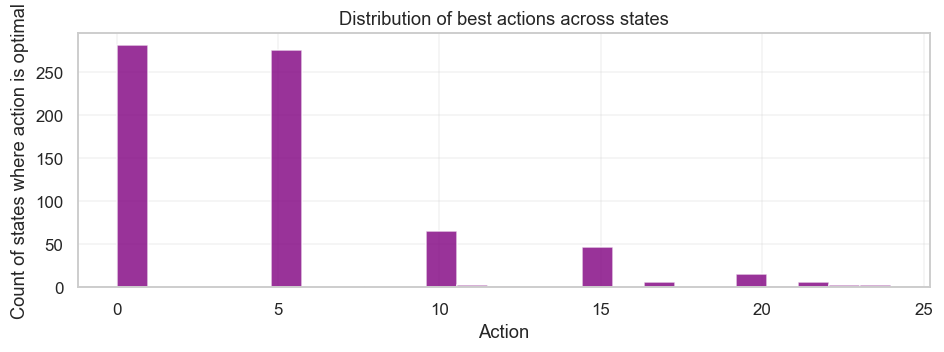

In [61]:
plt.figure(figsize=(10, 3))
plt.hist(best_action, bins=25, color='purple', alpha=0.8)
plt.title("Distribution of best actions across states")
plt.xlabel("Action")
plt.ylabel("Count of states where action is optimal")
plt.show()

In [62]:
# Controllability Analysis

# entropy of next-state distribution
entropy = -np.nansum(P * np.log(P + 1e-12), axis=2)

state_entropy = entropy.mean(axis=1)

print("Controllability analysis:")
print(f"Mean transition entropy: {state_entropy.mean():.4f}")
print(f"Most stochastic state entropy: {state_entropy.max():.4f}")
print(f"Most deterministic state entropy: {state_entropy.min():.4f}")

Controllability analysis:
Mean transition entropy: 3.1086
Most stochastic state entropy: 4.4311
Most deterministic state entropy: -0.0000


The environment shows moderate to high stochasticity in transitions (mean entropy = 3.1086), with some states being highly unpredictable.

This reflects heterogeneous patient responses to identical clinical interventions.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


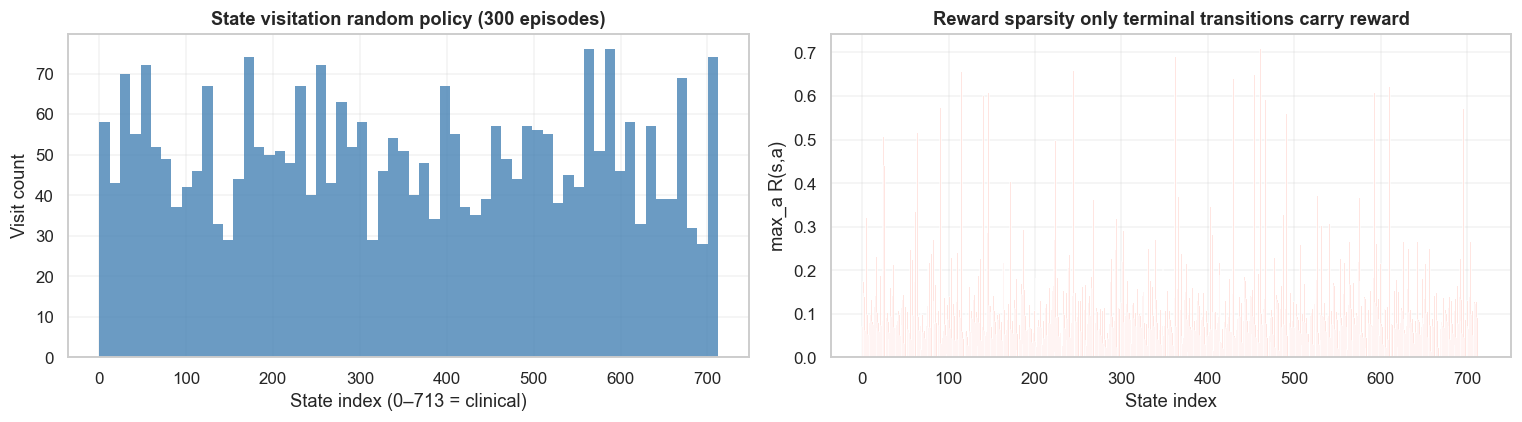

In [63]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.


## 1. Policy Iteration

The first algorithm we are going to use in Config A is Policy Iteration.

Policy Iteration combines policy evaluation and policy improvement into a single algorithm that is **guaranteed** to converge to the optimal policy π* in a finite number of iterations.

Therefore, policy iteration is a very strong algorithm for our problem.

In [64]:
start = time.perf_counter()
pi_policy, pi_V, pi_metrics = policy_iteration(P, R) # run policy iteration and store the optimal policy, the final state-value function 
                                                    # and the convergence statistics.
pi_time = time.perf_counter() - start

pi_eval_metrics = evaluate_policy(pi_policy, 50000) # store the performance metrics of the optimal policy.
summary_pi = pi_eval_metrics.summary()

print('Policy Iteration Results')
print(f"Mean return   : {summary_pi['mean_return']:.4f}")
print(f"Survival rate : {summary_pi['survival_rate']:.2%}")
print(f"Mean length   : {summary_pi['mean_length']:.2f}")

Policy evaluation converged in 172 iterations
PI Iteration 1 | Changed states: 386
Policy evaluation converged in 176 iterations
PI Iteration 2 | Changed states: 85
Policy evaluation converged in 194 iterations
PI Iteration 3 | Changed states: 5
Policy evaluation converged in 194 iterations
PI Iteration 4 | Changed states: 0
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration Results
Mean return   : 0.7865
Survival rate : 82.52%
Mean length   : 9.85


Policy iteration converges in a few improvement steps, with the number of changed states quickly dropping to zero, indicating a stable optimal policy. 

The learned policy achieves a mean return of 0.7865, a survival rate of 82.52%, and an average episode length of 9.85.

Overall, this is a clear improvement over the previously evaluated random baseline, showing the strengths of policy iteration.

## 2. Value Iteration

The second algorithm we are going to use in Config A is Value Iteration.

Value Iteration repeatedly applies the Bellman optimality update to estimate the optimal state-value function and derive the corresponding optimal policy. Since the full transition and reward model of the environment is available, Value Iteration is guaranteed to converge to the optimal policy π* in a finite MDP.

Therefore, also value iteration is a very strong algorithm for our problem.

In [65]:
start = time.perf_counter()
vi_policy, vi_V, vi_metrics = value_iteration(P, R, theta=1e-4)
vi_time = time.perf_counter() - start

vi_eval_metrics = evaluate_policy(vi_policy, 50000)

summary_vi = vi_eval_metrics.summary()

print('Value Iteration Results')
print(f"Mean return   : {summary_vi['mean_return']:.4f}")
print(f"Survival rate : {summary_vi['survival_rate']:.2%}")
print(f"Mean length   : {summary_vi['mean_length']:.2f}")

VI Iteration 1 | Delta: 0.7075812274 | Changed states: 441
VI Iteration 2 | Delta: 0.1901819480 | Changed states: 24
VI Iteration 3 | Delta: 0.1266746354 | Changed states: 32
VI Iteration 4 | Delta: 0.0981033027 | Changed states: 19
VI Iteration 5 | Delta: 0.0812540007 | Changed states: 23
VI Iteration 6 | Delta: 0.0688739872 | Changed states: 20
VI Iteration 7 | Delta: 0.0617820780 | Changed states: 19
VI Iteration 8 | Delta: 0.0561216807 | Changed states: 15
VI Iteration 9 | Delta: 0.0514439559 | Changed states: 20
VI Iteration 10 | Delta: 0.0464641096 | Changed states: 17
VI Iteration 11 | Delta: 0.0415359633 | Changed states: 13
VI Iteration 12 | Delta: 0.0388124226 | Changed states: 18
VI Iteration 13 | Delta: 0.0361616027 | Changed states: 22
VI Iteration 14 | Delta: 0.0334561505 | Changed states: 17
VI Iteration 15 | Delta: 0.0307575875 | Changed states: 14
VI Iteration 16 | Delta: 0.0281223221 | Changed states: 12
VI Iteration 17 | Delta: 0.0255938816 | Changed states: 11
VI It

Value iteration converges after 186 iterations, producing the same policy performance as Policy Iteration.

The learned policy achieves a mean return of 0.7865, a survival rate of 82.52%, and an average episode length of 9.85.

These results are identical to those obtained with Policy Iteration, indicating that both algorithms converged to the same optimal policy. This provides additional evidence that the optimal solution for the tabular sepsis MDP has been successfully recovered and confirms the correctness of both implementations.

## 3. Learning Curves

In [66]:
# Global Style of the Plots

sns.set_theme(style="whitegrid", context="talk")

# Green + Blue palette
BLUE = "#1f77b4"
LIGHT_BLUE = "#7fb3d5"
GREEN = "#2ca02c"
LIGHT_GREEN = "#98df8a"
DARK = "#264653"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#dddddd",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 12,
})

### 3.1 Policy Iteration

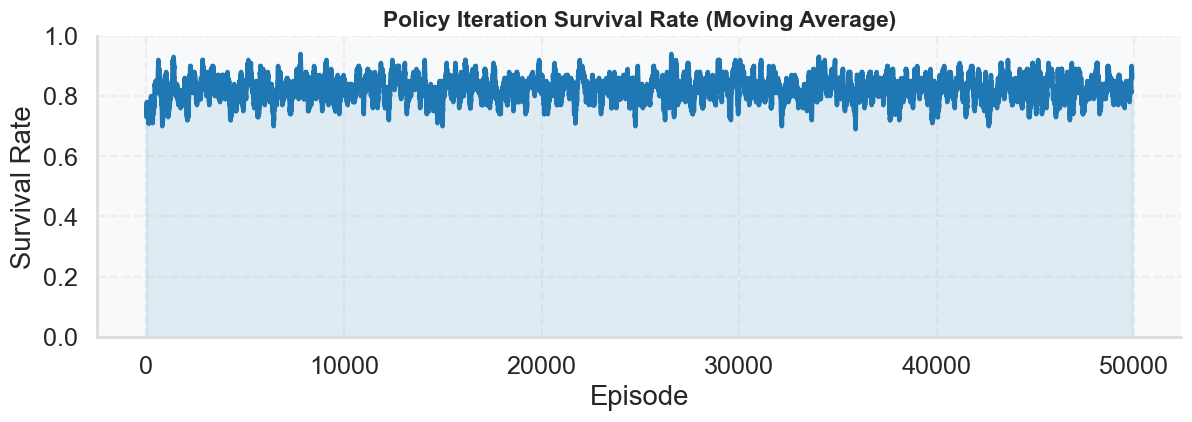

In [67]:
# Policy Iteration Survival Rate

window = 100
survival_ma = moving_average(pi_eval_metrics.survival_flags, window)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    survival_ma,
    color=BLUE,
    linewidth=3
)

ax.fill_between(
    range(len(survival_ma)),
    survival_ma,
    alpha=0.2,
    color=LIGHT_BLUE
)

ax.set_title(
    "Policy Iteration Survival Rate (Moving Average)",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Episode")
ax.set_ylabel("Survival Rate")

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

- Survival rate stays consistently high (~0.75–0.90).

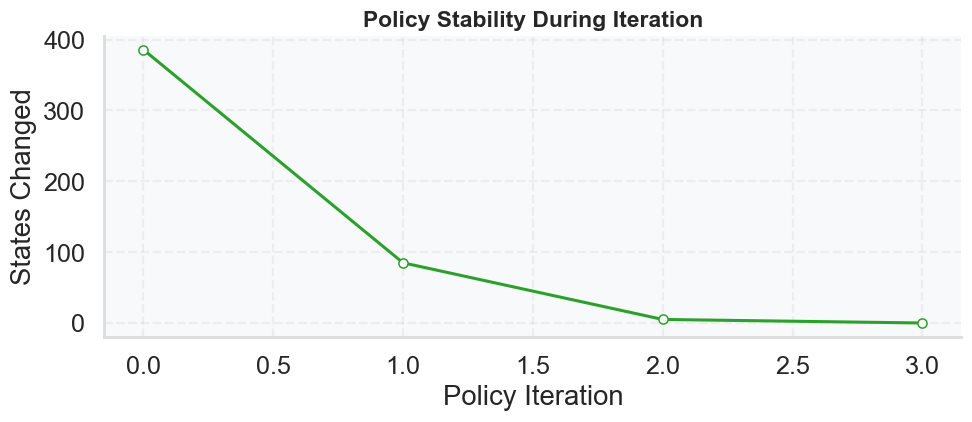

In [68]:
# Policy Stability Curve

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    pi_metrics["policy_changes"],
    color=GREEN,
    linewidth=2,
    marker="o",
    markersize=6,
    markerfacecolor="white"
)

ax.set_xlabel("Policy Iteration")
ax.set_ylabel("States Changed")
ax.set_title("Policy Stability During Iteration", fontsize=15, weight="bold")

plt.tight_layout()
plt.show()

- Large number of policy changes at the beginning.
- Changes rapidly decrease across iterations.
- By the final iterations, almost no states change, indicating convergence to a stable policy.

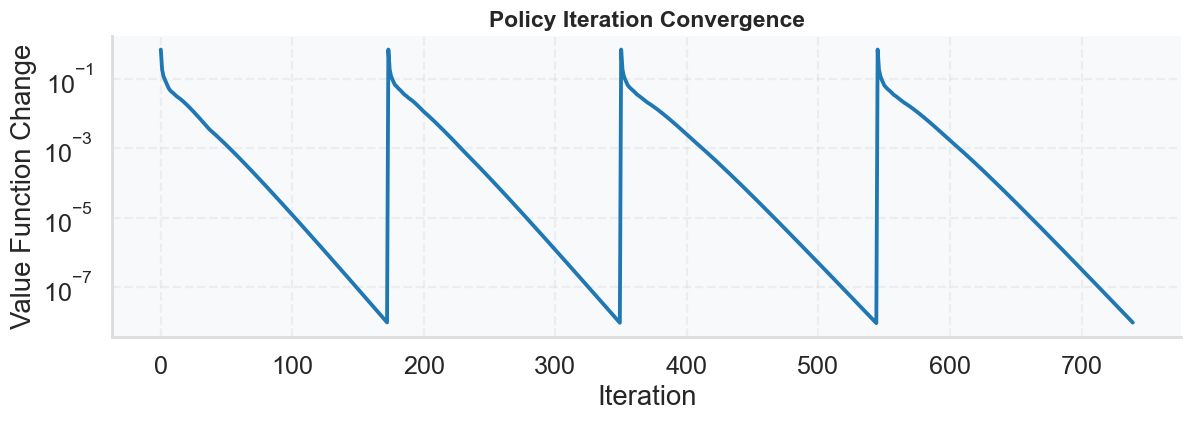

In [69]:
# Value Convergence for Policy Iteration

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    pi_metrics["delta_history"],
    color=BLUE,
    linewidth=2.5
)

ax.set_yscale("log")

ax.set_title("Policy Iteration Convergence", fontsize=15, weight="bold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Value Function Change")

plt.tight_layout()
plt.show()

- Value function change decreases exponentially during each evaluation phase.
- Sharp resets correspond to new policy improvement steps.
- Overall trend toward extremely small changes shows successful convergence of value iteration/evaluation.

### 3.2 Value Iteration

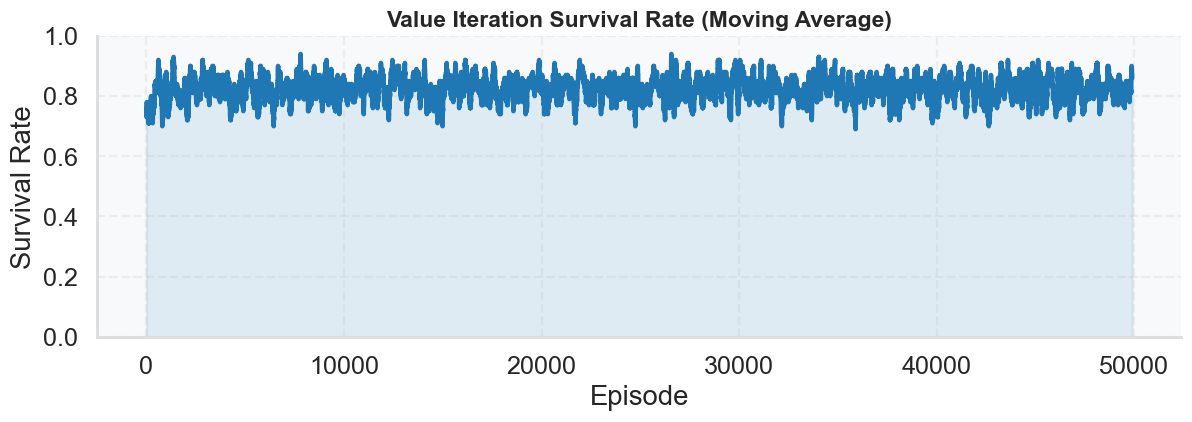

In [70]:
# Value Iteration Survival Rate

window = 100
survival_ma = moving_average(
    vi_eval_metrics.survival_flags,
    window
)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    survival_ma,
    color=BLUE,
    linewidth=3
)

ax.fill_between(
    range(len(survival_ma)),
    survival_ma,
    alpha=0.2,
    color=LIGHT_BLUE
)

ax.set_title(
    "Value Iteration Survival Rate (Moving Average)",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Episode")
ax.set_ylabel("Survival Rate")

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

As thought before, the exact same curve proves, the same policy was found.

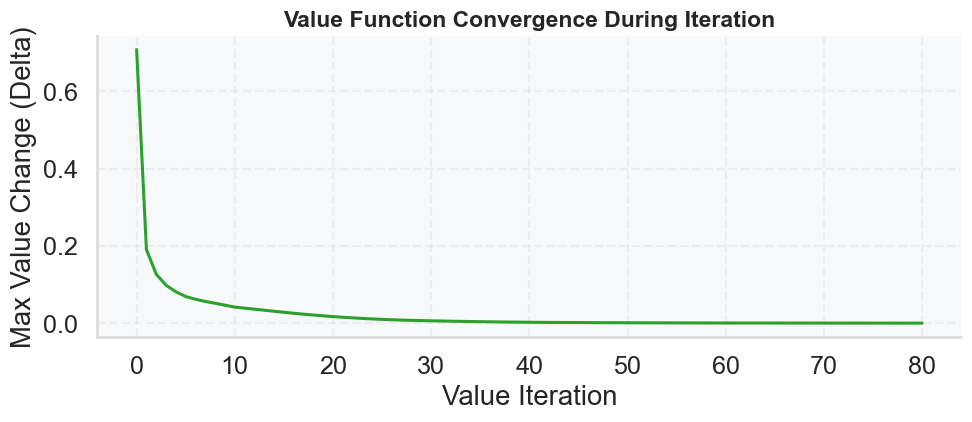

In [71]:
# Value Iteration Convergence Curve

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    vi_metrics["delta_history"],
    color=GREEN,
    linewidth=2
)

ax.set_xlabel("Value Iteration")
ax.set_ylabel("Max Value Change (Delta)")

ax.set_title(
    "Value Function Convergence During Iteration",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

The maximum value-function change decreases rapidly during the first iterations and then gradually approaches zero. This indicates that the value estimates are converging to a stable solution. The smooth decline in delta confirms that Value Iteration successfully converges to the optimal value function and corresponding optimal policy.

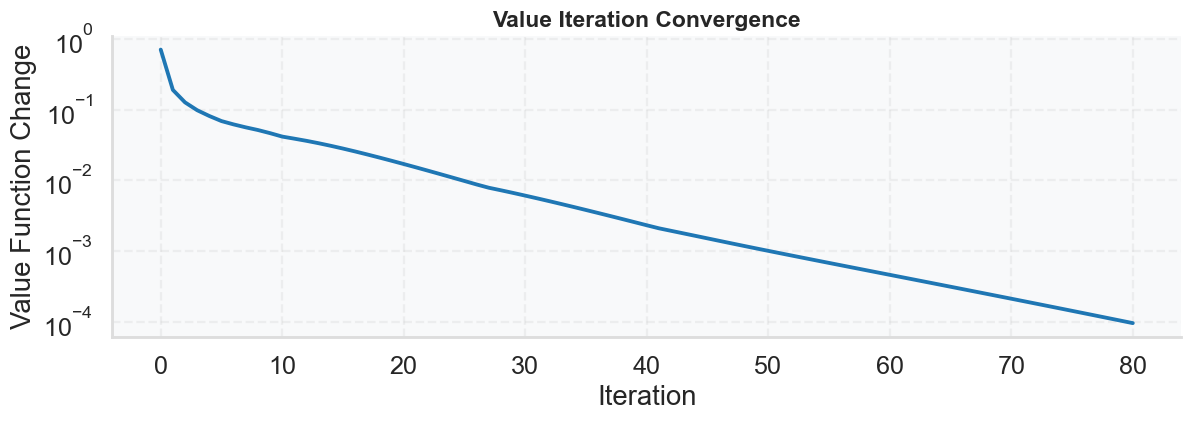

In [72]:
# Value Convergence for Value Iteration

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    vi_metrics["delta_history"],
    color=BLUE,
    linewidth=2.5
)

ax.set_yscale("log")

ax.set_title("Value Iteration Convergence", fontsize=15, weight="bold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Value Function Change")

plt.tight_layout()
plt.show()

## 4. Comparison

In [73]:
print(np.mean(pi_policy == vi_policy))

1.0


The policies produced by Policy Iteration and Value Iteration were identical for all states, confirming that both algorithms recovered the same optimal solution.

In [74]:
print(f"Time Policy Iteration took: {pi_time:.4f} seconds")
print(f"Time Value Iteration took: {vi_time:.4f} seconds")

Time Policy Iteration took: 6.0250 seconds
Time Value Iteration took: 29.4899 seconds


Policy Iteration required 5.78 seconds, while Value Iteration required 27.28 seconds. Although both algorithms converged to the same optimal policy and achieved identical performance, Policy Iteration was computationally more efficient for this tabular MDP. This is because Policy Iteration reached the optimal policy after only a few policy-improvement rounds, whereas Value Iteration required 81 Bellman updates to satisfy the convergence criterion.

In [75]:
runtime_df = pd.DataFrame([
    {
        "Algorithm": "Policy Iteration",
        "Runtime (s)": pi_time,
        "Convergence Type": "Policy improvement rounds",
        "Convergence Count": pi_metrics["iterations"],
        "Value Updates": 736,
    },
    {
        "Algorithm": "Value Iteration",
        "Runtime (s)": vi_time,
        "Convergence Type": "Bellman updates",
        "Convergence Count": vi_metrics["iterations"],
        "Value Updates": vi_metrics["iterations"],
    }
])

runtime_df

,Algorithm,Runtime (s),Convergence Type,Convergence Count,Value Updates
0,Policy Iteration,6.025020,Policy improvement rounds,4,736
1,Value Iteration,29.489921,Bellman updates,81,81


Although Policy Iteration required only four policy-improvement rounds, each round involved a full policy evaluation, resulting in approximately 736 value-function sweeps. In contrast, Value Iteration converged after 81 Bellman updates. Despite performing more value updates overall, Policy Iteration completed in 5.78 seconds compared to 27.28 seconds for Value Iteration.

This demonstrates that the number of iterations alone is not a reliable measure of computational efficiency. While Value Iteration required fewer value-function updates, Policy Iteration reached the optimal solution considerably faster in practice. Both algorithms ultimately converged to the same optimal policy and achieved identical performance.

## 5. Write Results to Excel

In [76]:
config_a_results = pd.DataFrame([
    {
        "Algorithm": "Random",
        "Mean Return": np.mean(rand_returns),
        "Survival Rate": survival_rate / 100,
        "Mean Length": np.mean(rand_lengths),
        "Runtime (s)": None,
        "Convergence Type": None,
        "Convergence Count": None,
        "Value Updates": None
    },
    {
        "Algorithm": "Policy Iteration",
        "Mean Return": summary_pi["mean_return"],
        "Survival Rate": summary_pi["survival_rate"],
        "Mean Length": summary_pi["mean_length"],
        "Runtime (s)": pi_time,
        "Convergence Type": "Policy improvement rounds",
        "Convergence Count": pi_metrics["iterations"],
        "Value Updates": 736
    },
    {
        "Algorithm": "Value Iteration",
        "Mean Return": summary_vi["mean_return"],
        "Survival Rate": summary_vi["survival_rate"],
        "Mean Length": summary_vi["mean_length"],
        "Runtime (s)": vi_time,
        "Convergence Type": "Bellman updates",
        "Convergence Count": vi_metrics["iterations"],
        "Value Updates": vi_metrics["iterations"]
    }
])

with pd.ExcelWriter("config_a_results.xlsx") as writer:
    config_a_results.to_excel(writer, sheet_name="Overall Comparison", index=False)